In [1]:
import pandas as pd
import numpy as np
import math as mt
import matplotlib.pyplot as plt
from scipy.stats import *
import geopandas as gpd

In [2]:
path='donnees_communes/'
france = gpd.read_file(path+"departements.geojson")
world = gpd.read_file(path+"countries.geojson")

In [3]:
data_communes = pd.read_csv(path+'RGC_2013.csv',sep=';',dtype={'DEP': str,'COM' : str})
data_emplois=pd.read_csv(path+'Emplois_salaries.csv',sep=';',dtype={'CODGEO': str})
#Traitement préalable des données à effectuer
data_communes.insert(2,'COG',data_communes.DEP + data_communes.COM.str.zfill(3))

In [4]:
def associate_arr_mun(num_dep,cog,num_arr_debut,num_arr_fin):
    list_arr_com=[str(num_dep)+str(num_arr).zfill(3) for num_arr in \
                  range(num_arr_debut,num_arr_fin+1)]
    mask=data_emplois['CODGEO'].str.zfill(5).isin(list_arr_com)
    data_emplois_commune=data_emplois[mask].sum()
    data_emplois_commune['CODGEO']=str(cog)
    data_emplois.loc[len(data_emplois)]=data_emplois_commune.values

In [5]:
associate_arr_mun(75,75056,101,120)
associate_arr_mun(13,13055,201,216)
associate_arr_mun(69,69123,381,389)

      DEP  COM    COG  ARRD  CANT  ADMI  POPU  SURFACE          NOM  XLAMB2  \
0       1  445   1445     2    11     6     6     1386  VILLEMOTIER    8297   
1       1   98   1098     1     4     6     7     1059  CHAZEY-BONS    8600   
2       1   57   1057     2    26     6     5      731          BOZ    7978   
3       1  149   1149     1     1     6    10      526      DOUVRES    8352   
4       1  436   1436     3    14     6     5     1070      VESANCY    8888   
...    ..  ...    ...   ...   ...   ...   ...      ...          ...     ...   
34818  2B   58  2B058     2     9     6     3     1667       CANARI   11722   
34819  2B   43  2B043     2     9     5    16     2222       BRANDO   11848   
34820  2B  178  2B178     2     9     6     1      804        NONZA   11740   
34821  2B   33  2B033     2    99     3   430     1938       BASTIA   11834   
34822  2B   29  2B029     5    29     6     2     1086    BARBAGGIO   11776   

       ...  EFF_BE_200_499  EFF_FZ_200_499  EFF_GU_

{'whiskers': [<matplotlib.lines.Line2D at 0x7f62c189b610>,
 'caps': [<matplotlib.lines.Line2D at 0x7f62c189b890>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f62c189b4d0>],
 'medians': [<matplotlib.lines.Line2D at 0x7f62c189bb10>],
 'fliers': [],
 'means': [<matplotlib.lines.Line2D at 0x7f62c189bc50>]}

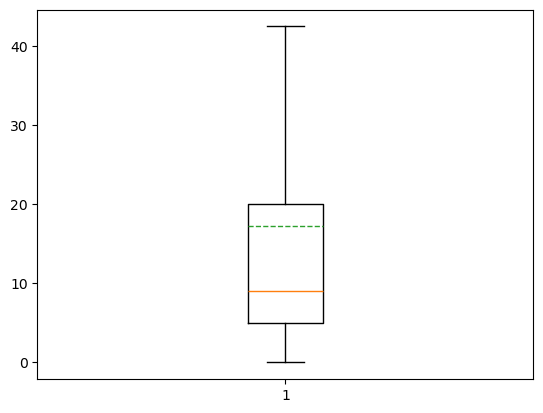

In [40]:
#Question 3.2
jsp = data_communes.merge(data_emplois, left_on="COG",right_on="CODGEO")
mask = jsp.loc[jsp["POPU"] != 0]
print(mask)
ratio = (mask["EFF_TOT"]/mask["POPU"])
#ratio = ratio*10
ratio.dropna(inplace=True)
print(ratio.mean())
plt.boxplot(ratio,showfliers=False,meanline=True, showmeans=True)

Expliquer ici la différence entre moyenne et médiane. Par ailleurs quel indicateur statistique pourrait-on utiliser pour quantifier la dispersion des données ?

In [ ]:
#Question 3.3
data_emploi

In [ ]:
#calculs à effectuer pour rajouter la densité de population (DENS) par département


In [1]:
#Carte densité par départements
france_map =#jointure à effectuer
print('type dataframe jointure : ',type(france_map))
france_map = gpd.GeoDataFrame(france_map)
fig, ax = plt.subplots(1, figsize=(9,8))
# On crée 5 catégories en utilisant des quantiles (la notion de quantiles est un terme générique, avec 4 catégories on subdivise les quantiles sont des quartiles et avec 10 catégories les quantiles sont des déciles)
france_map.plot(ax=ax, 
                column='DENS', 
                cmap='GnBu', #https://matplotlib.org/stable/tutorials/colors/colormaps.html  YlOrRd
                scheme='quantiles', 
                k=5, 
                legend=True,legend_kwds={'loc':'center left','bbox_to_anchor':(-0.1, 0.5)})

ax.axis('off')
plt.title("Densité population par département", fontsize=15)
ax.annotate('Année: 2013', xy=(0.1, .15), 
                                   xycoords='figure fraction', 
                                   horizontalalignment='left', 
                                   verticalalignment='top', 
                                   fontsize=12, 
                                   color='#555555')
plt.show()

SyntaxError: invalid syntax (1219499207.py, line 2)

Interpréter précisément ici la signification des données représentées sur les départements avec la teinte la plus claire

In [ ]:
#Cartes avec qqs communes

fig, ax = plt.subplots(1, figsize=(10,10))
world_map = gpd.GeoDataFrame(world)
world_map.plot(ax=ax)
geom_points=gpd.points_from_xy(data_communes.LONGI_DMS/10000, data_communes.LATI_DMS/10000)
gdf = gpd.GeoDataFrame(data_communes, geometry=geom_points)
#gdf_pcpx=Ne garder ici que les 7 villes les plus peuplées


ax.set_xlim(-5, 10)
ax.set_ylim(42, 52)

gdf_pcpx.plot(ax=ax,markersize=.......,color='r',edgecolor='black')

for x, y, label in zip(gdf_pcpx.geometry.x, gdf_pcpx.geometry.y, gdf_pcpx.NOM):
    ax.annotate(label, xy=(x, y), xytext=(3, 3), textcoords="offset points")
plt.show()
